In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
from glob import glob
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to import logger, VR-wide constants and device paths
sys.path.append(os.path.join('.', ".."))
from baseVR.base_logger import CustomLogger as Logger
from baseVR.base_functionality import device_paths

import mea1k_modules.mea1k_visualizations as vis
from mea1k_connectivity_scripts.analyze_extSine_connectivity import extract_connectivity, vis_connectivity, create_implant_dir, get_connectivity_data
from mea1k_connectivity_scripts.analyze_shortcut_stim import plot_amplitude_ridges, connected_islands, plot_3x3_short_results

from mea1k_utils import load_impedance_data as load_impedance_data

nas_dir = device_paths()[0]

In [ ]:
L = Logger()
L.init_logger(None, None, "WARNING")

## ACF try10
### Assembled on Friday: 20.7, 10 days after first succesful ACF try, in MEA22 dir, called "_ACF_Try10_PT5"
#### Approach:
* Used an old 8shank electrode to connect ACF film (full cover)
* Also put EcoFlex 00-30, went from very low pressure to higher 

#### Qustions:
* Can the ACF film connect to electrode with low impedance? 
    * -->  Yes, can work. Still had this strange 0.4 max connectivity still. somehow realted to maybe shorting GND and Ref with a wire?
    At lower pressure some connection started to show up, it then become quickly more with pressure. Then high press (PT5) destroyed most of it. IMpedance followed, but measurements still a bit off (same as MEA23 measured in the morning)
* Interestingly, they shift with each press, something i think i saw before with previous Try9
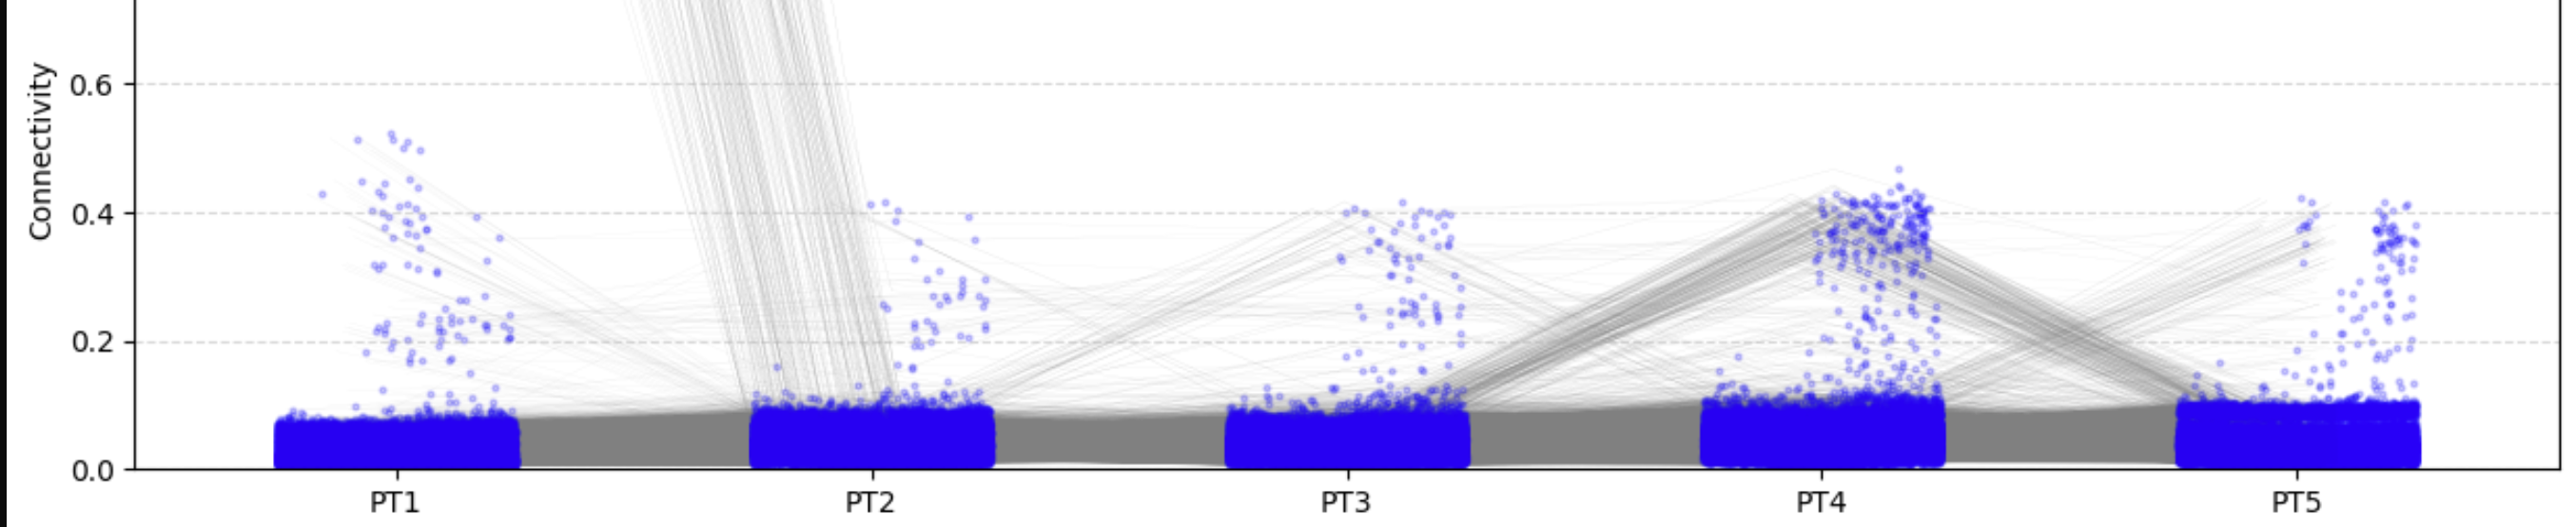

* impedance measures are messy. Electrodes are also porbably not in good condition, but there are some low impedance ones, showing that in princple a low imp connection can be made: 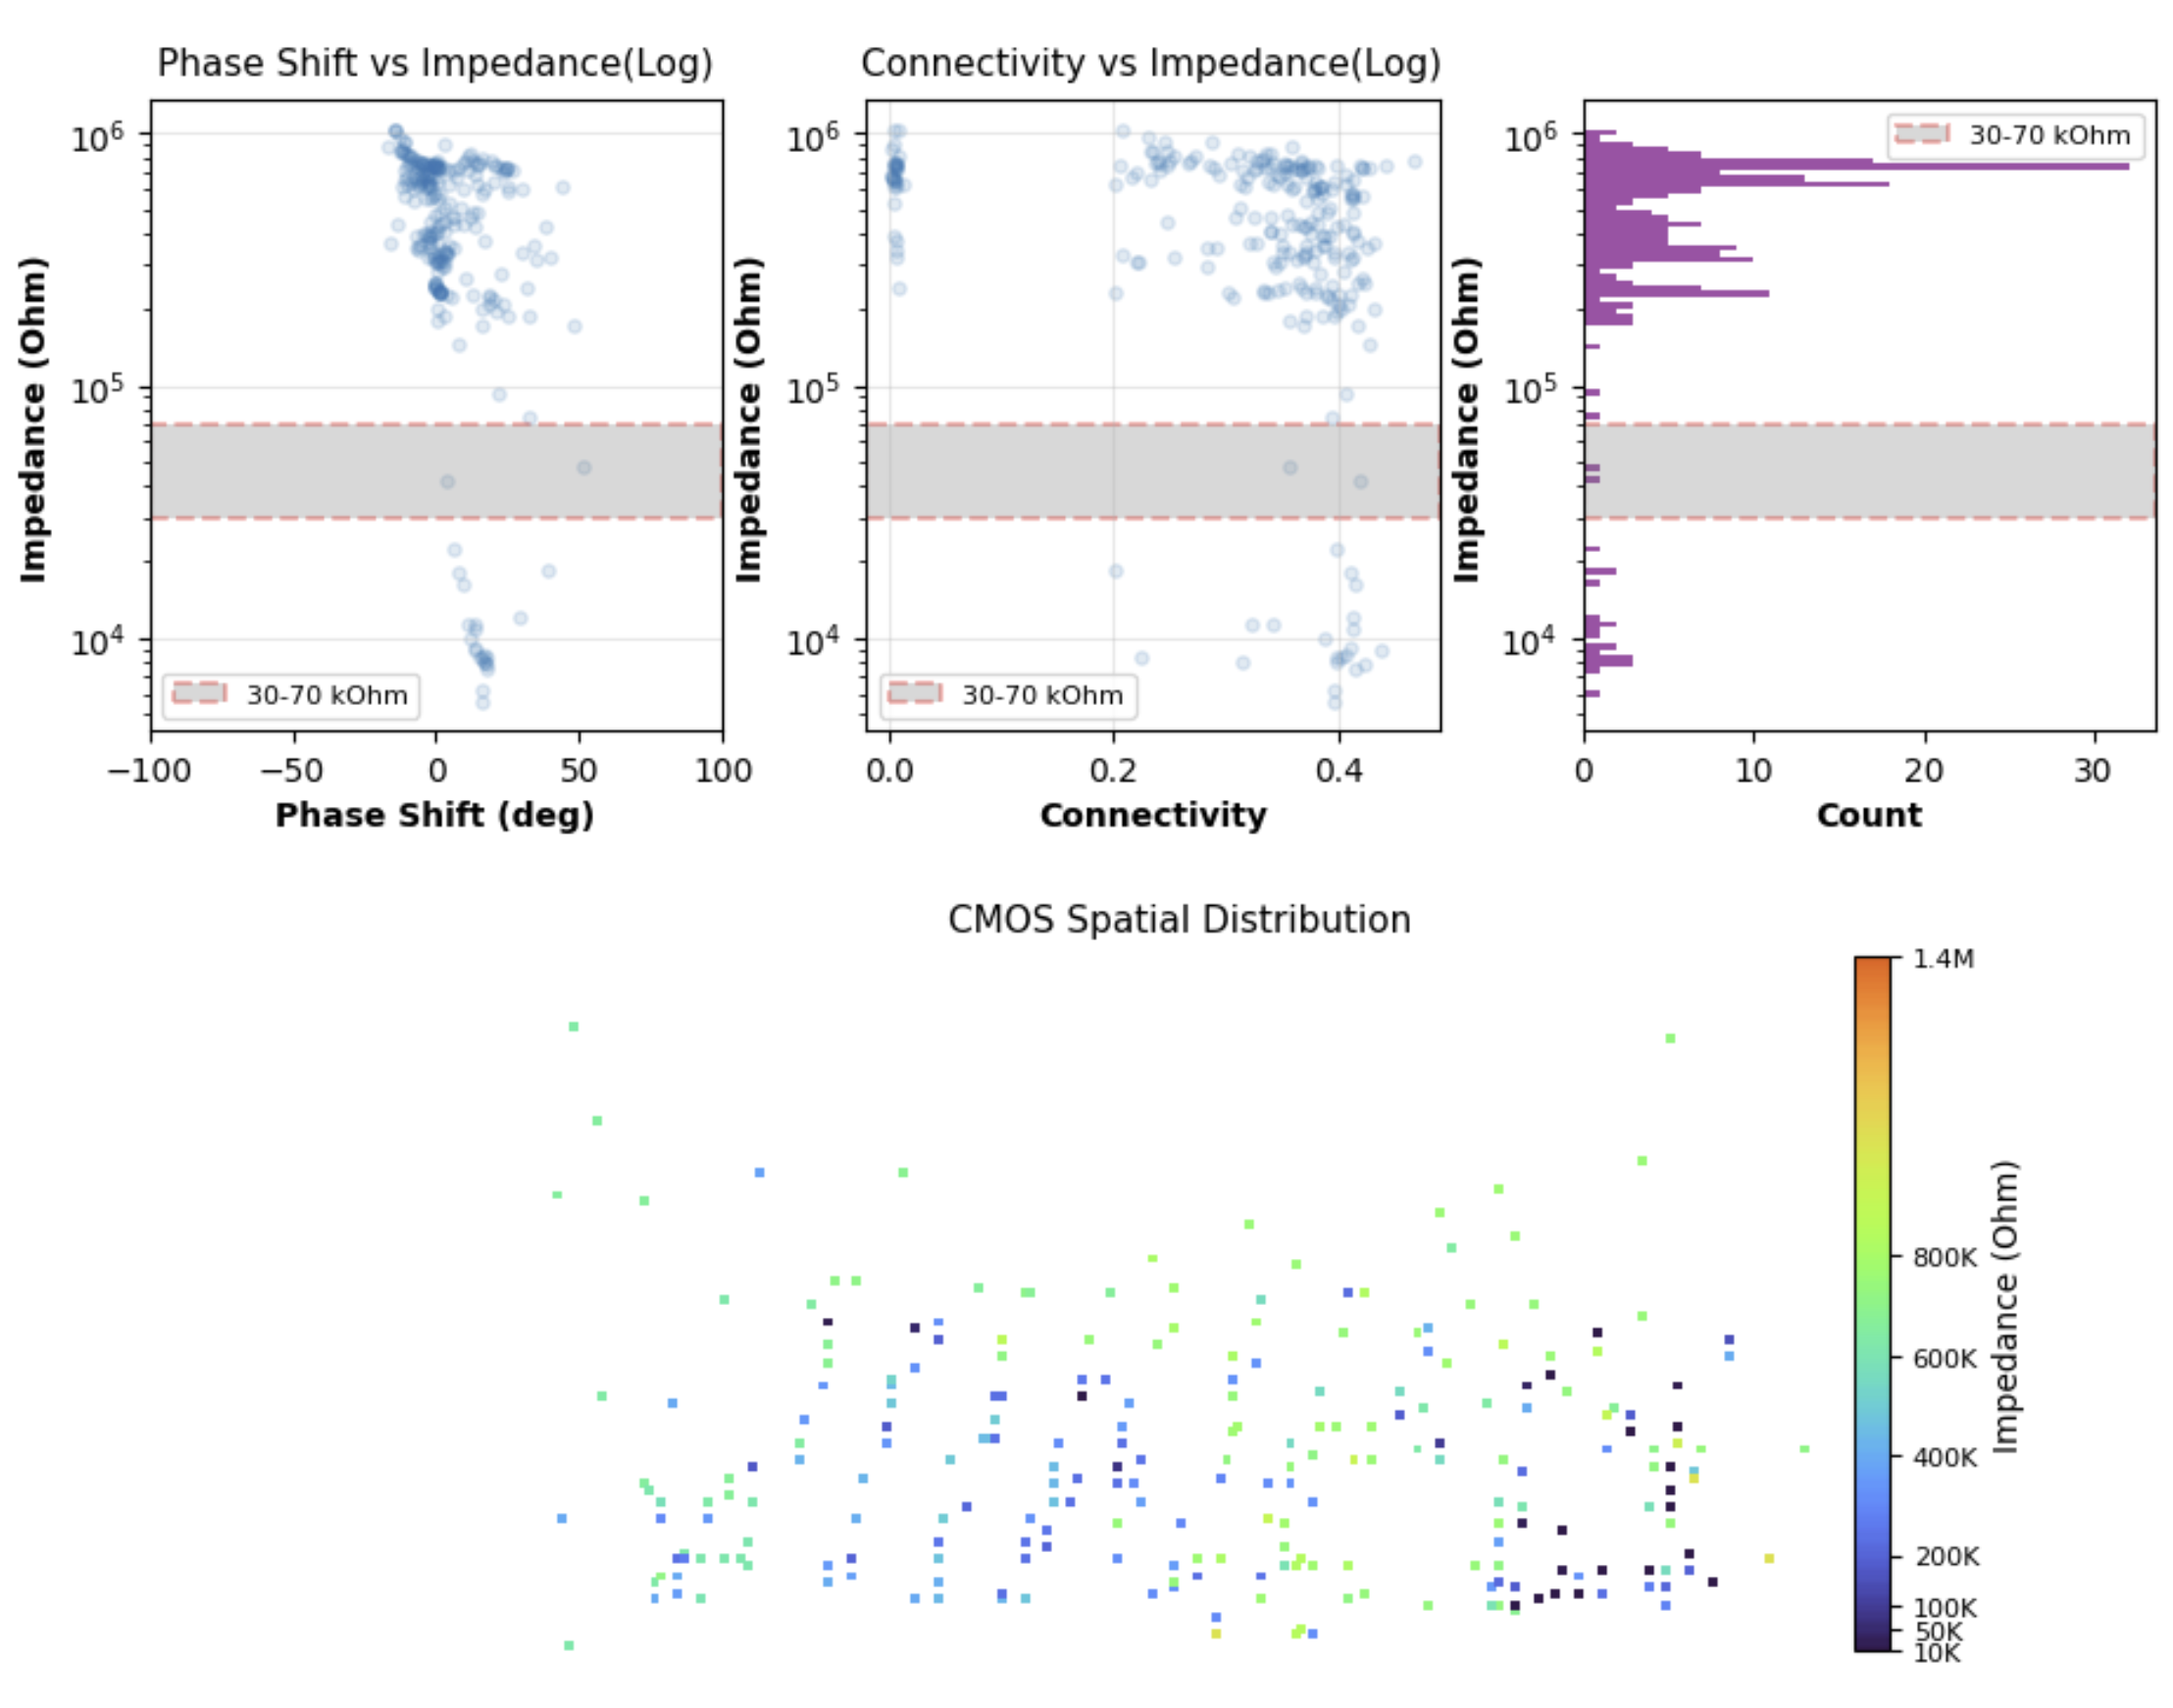

In [ ]:
headstage_name = "MEA1K22"
bonding_date = '260720'
HEADSTAGE_DEVICE_NAME = 'MEA1K22'
ELECTRODE_DEVICE_NAME = 'S844pad6shank'
batch = 1
IMPLANT_DEVICE_NAME = f"{bonding_date}_{HEADSTAGE_DEVICE_NAME}_{ELECTRODE_DEVICE_NAME}B{batch}"

subdir = f"devices/headstage_devices/{headstage_name}/recordings"
nas_dir = device_paths()[0]

In [ ]:
# connectivity analysis
rec_names = [
    "2026-07-20_15.02_ACF_PIEl_VRefAmpl15_Try10_PT1",
    "2026-07-20_15.04_ACF_PIEl_VRefAmpl15_Try10_PT2",
    "2026-07-20_15.07_ACF_PIEl_VRefAmpl15_Try10_PT3",
    "2026-07-20_15.09_ACF_PIEl_VRefAmpl15_Try10_PT4",
    "2026-07-20_16.17_ACF_PIEl_VRefAmpl15_Try10_PT5_2mm",
]

data = []
for rec_name in rec_names:
    full_path = os.path.join(nas_dir, subdir, rec_name)
    # extract_connectivity(full_path, input_ampl_mV=10, n_samples=8000, debug=False, )
    # vis_connectivity(full_path, input_ampl_mV=10, cmap_scaler=1)
    
    conn = get_connectivity_data(full_path)
    vis.draw_mea1k(mapping=conn, fast=True,  )
    data.append(conn)
    print(rec_name)
    plt.show()
    
    # create_implant_dir(full_path, nas_dir, HEADSTAGE_DEVICE_NAME, IMPLANT_DEVICE_NAME)


In [ ]:
# compare over runs
vis.compare_many_connectivities(data, ['PT1', 'PT2', 'PT3', 'PT4', 'PT5'], )#ylims=(0,1))

In [ ]:
## impadeance

log_scale = True
rec_dir = "2026-07-20_15.56_ACF_PIEl_Try10_PT4_Imp1"
# rec_dir = "2026-07-20_16.22_ACF_PIEl_Try10_PT5_2mm_Imp2"

aggr_df, implant_mapping, full_recdir = load_impedance_data(rec_dir, nas_dir, subdir, )
vis.plot_impedance_analysis(rec_dir, aggr_df, log_scale=log_scale, skip_bottom=False, 
                            color_by_metal=False, use_imp_connectivity=True)
vis.plot_ext_current_comparison(aggr_df, diff_max=2_000_000, title="Small current mode")
 

## ACF Try9
### Assembled on Friday: 10.7, malertag, in MEA22 dir, called "_ACF_Try9_PT1-3"
#### Approach:
* Used silver point to short one side of ACF film, also immerse tiny wire there. 
* Then pressed w/o EcoFLex carefully.Connected GND to wire. 
* FOr the first time no short to ringnode afer many tries, could measure good imp:))
#### Qustions:
* How is the connectivity in this low pressure mode? Can it be imporved by increasing pressure?
    * -->  good, yield close 100%, in this Try mostly single electrodes show up, before more clusters of 2x, and more patchy (shown via short analysis, so single might have been hidde)
    * main concern is rather on polyimide side - need bigger pads... when wires are so small and sparse
    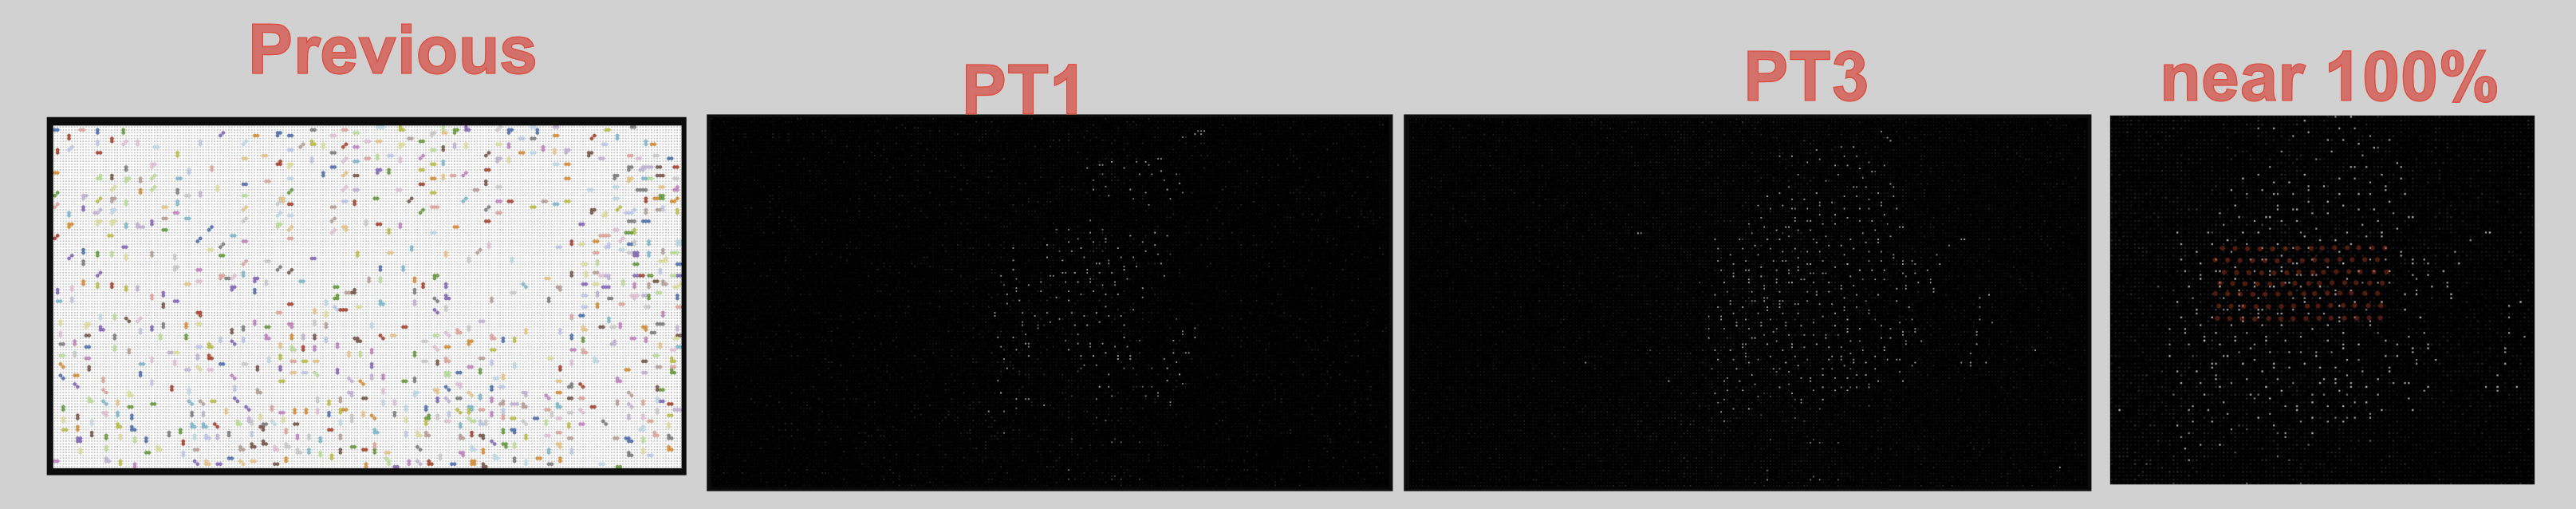
* Is it stable over days?
    * --> No, over 7 days, some shift, and every tigthening caused a shift by 2-3 electrodes! Haven't seen this before. Related to shape of EcoFLex after bonding? Creating sheer force?? But no, this doesn't have EcoFlex I am pretty sure.
    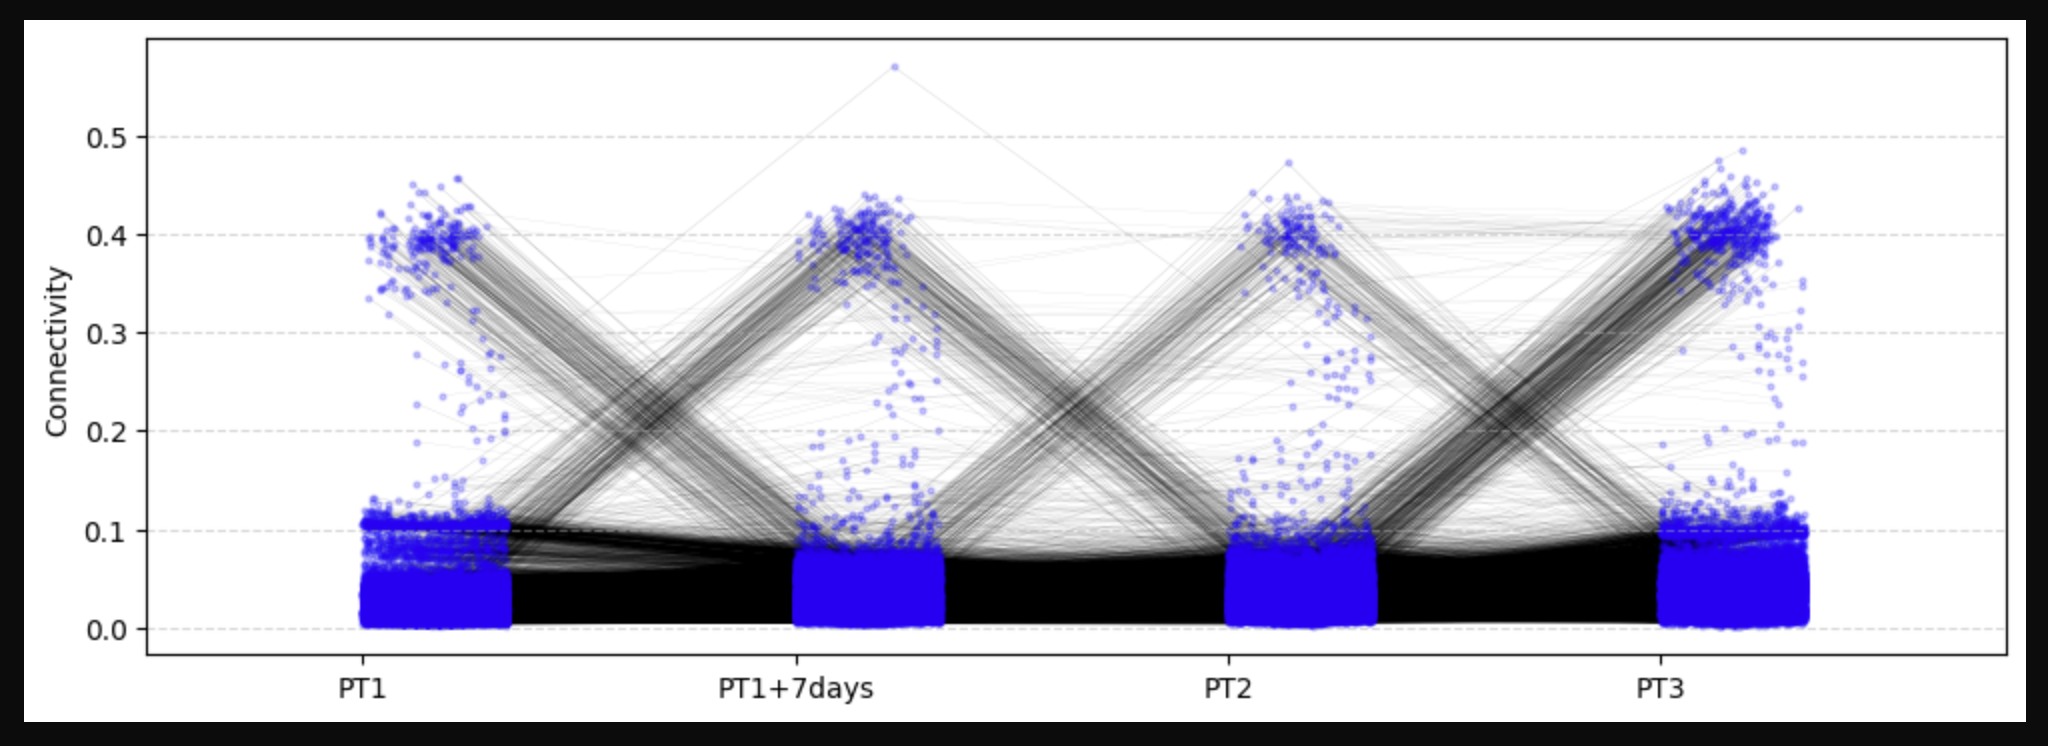

* Does high/ good connectivity imply an ohmic connection? Not like with other pads?
    * Yes, in 75-90% of cases: Pressure helps, but cannot really infer transfer if electrodes change like that.... Same in MEA24 recent bond?
    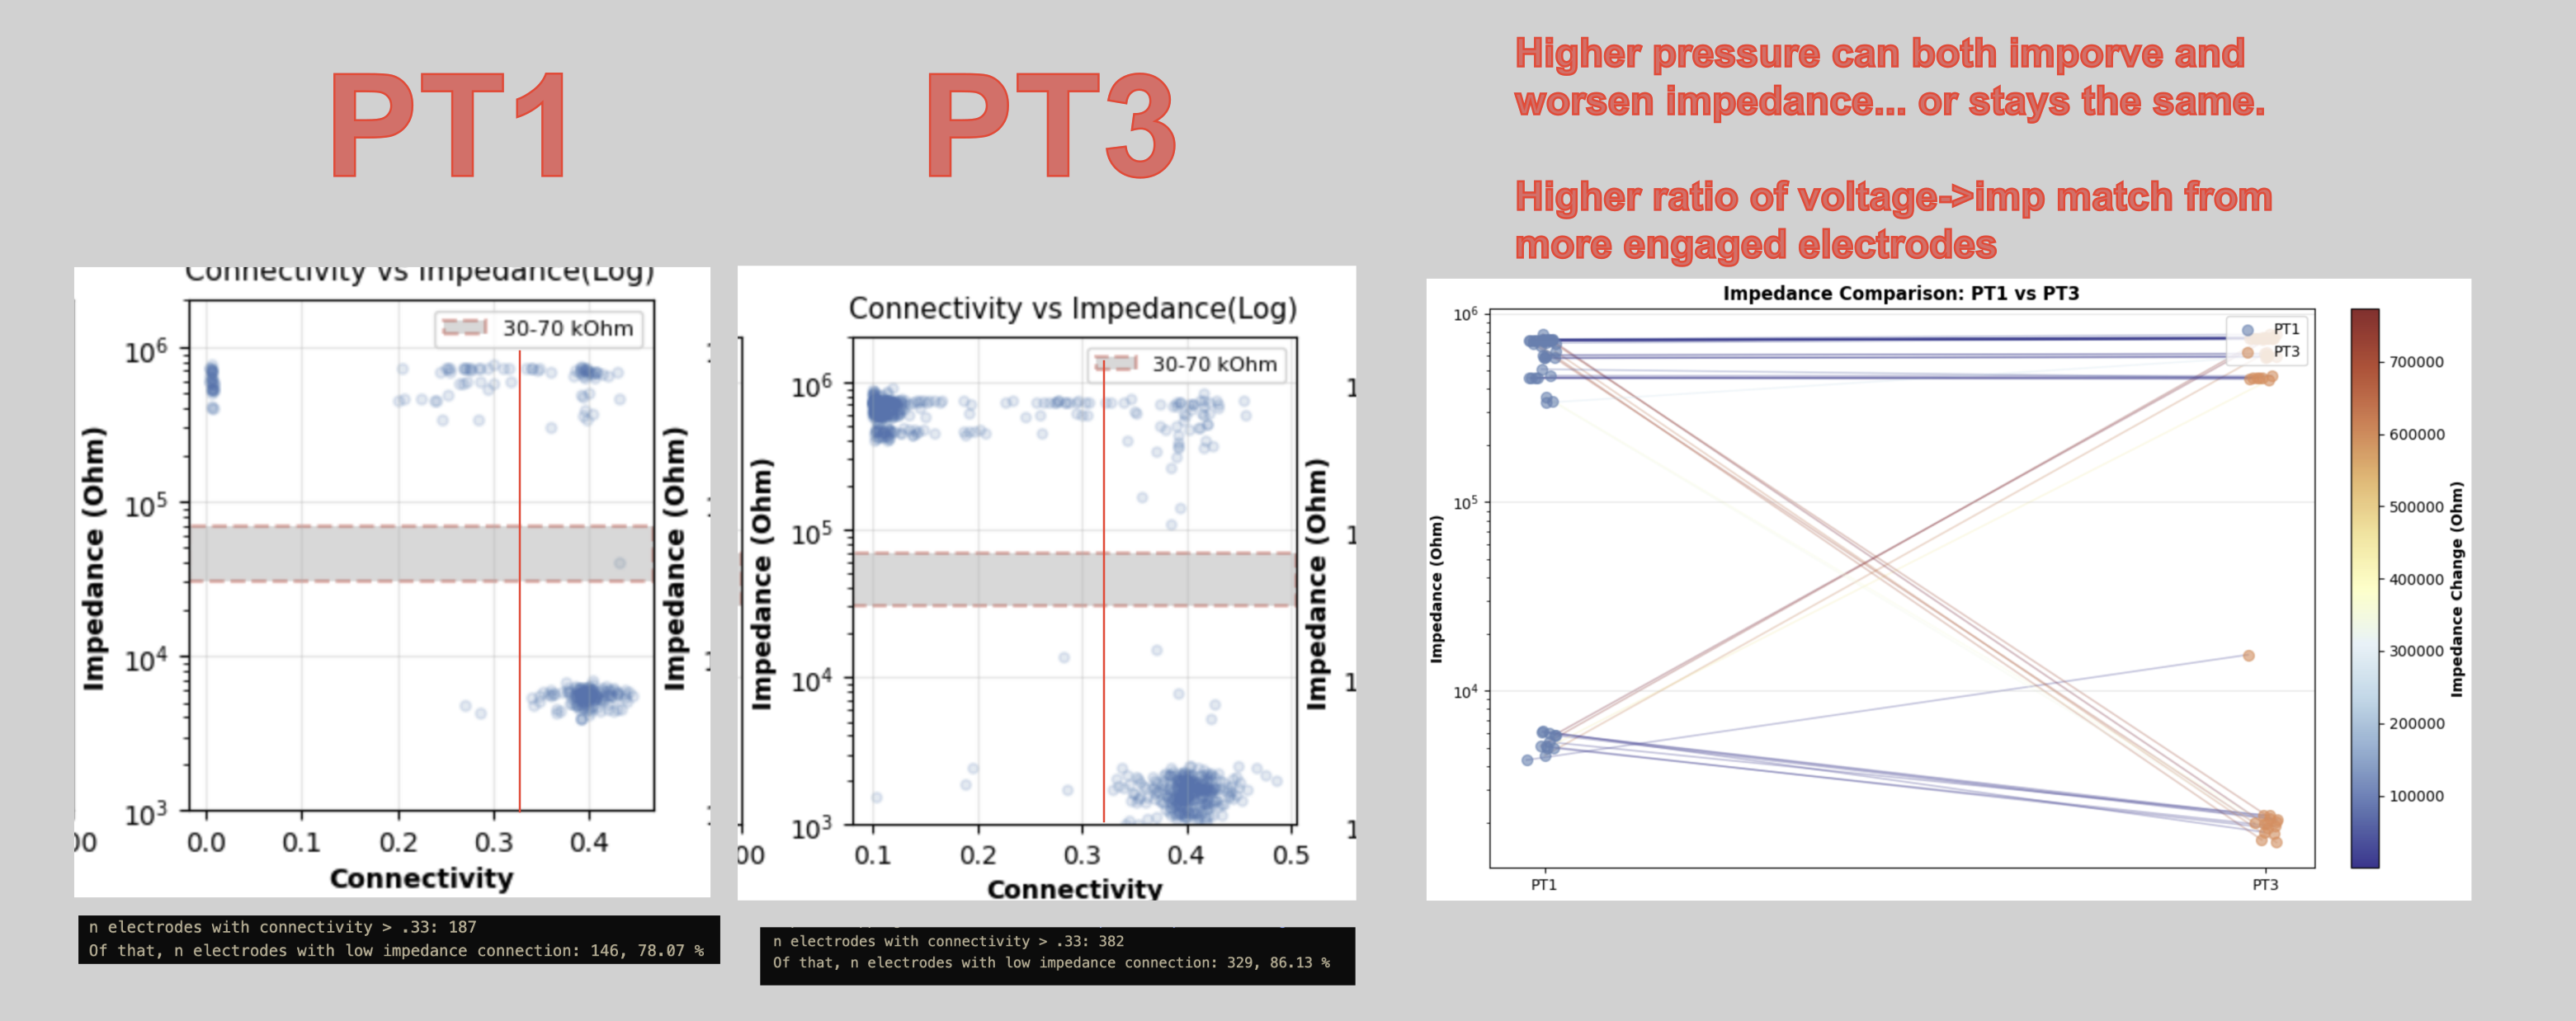

#### Unresolved:
* FPGA stimulation was locked to 4mV, not 10. I suspect some parasitic connection somewhere on chip surface?

#### Additional Notes:
* Saw quite a few shorts lterally (on short distance) between MEA electrodes, from history of pressing this film I assume, saw visially that it's affected by it
* Between PT1 and PT2 i tightened, then loosened again bc extenral signal was gone, likely shorted to GND ring
* There are shorts from previous attempts, did many. See shorts between neighbor mea1k el that are close
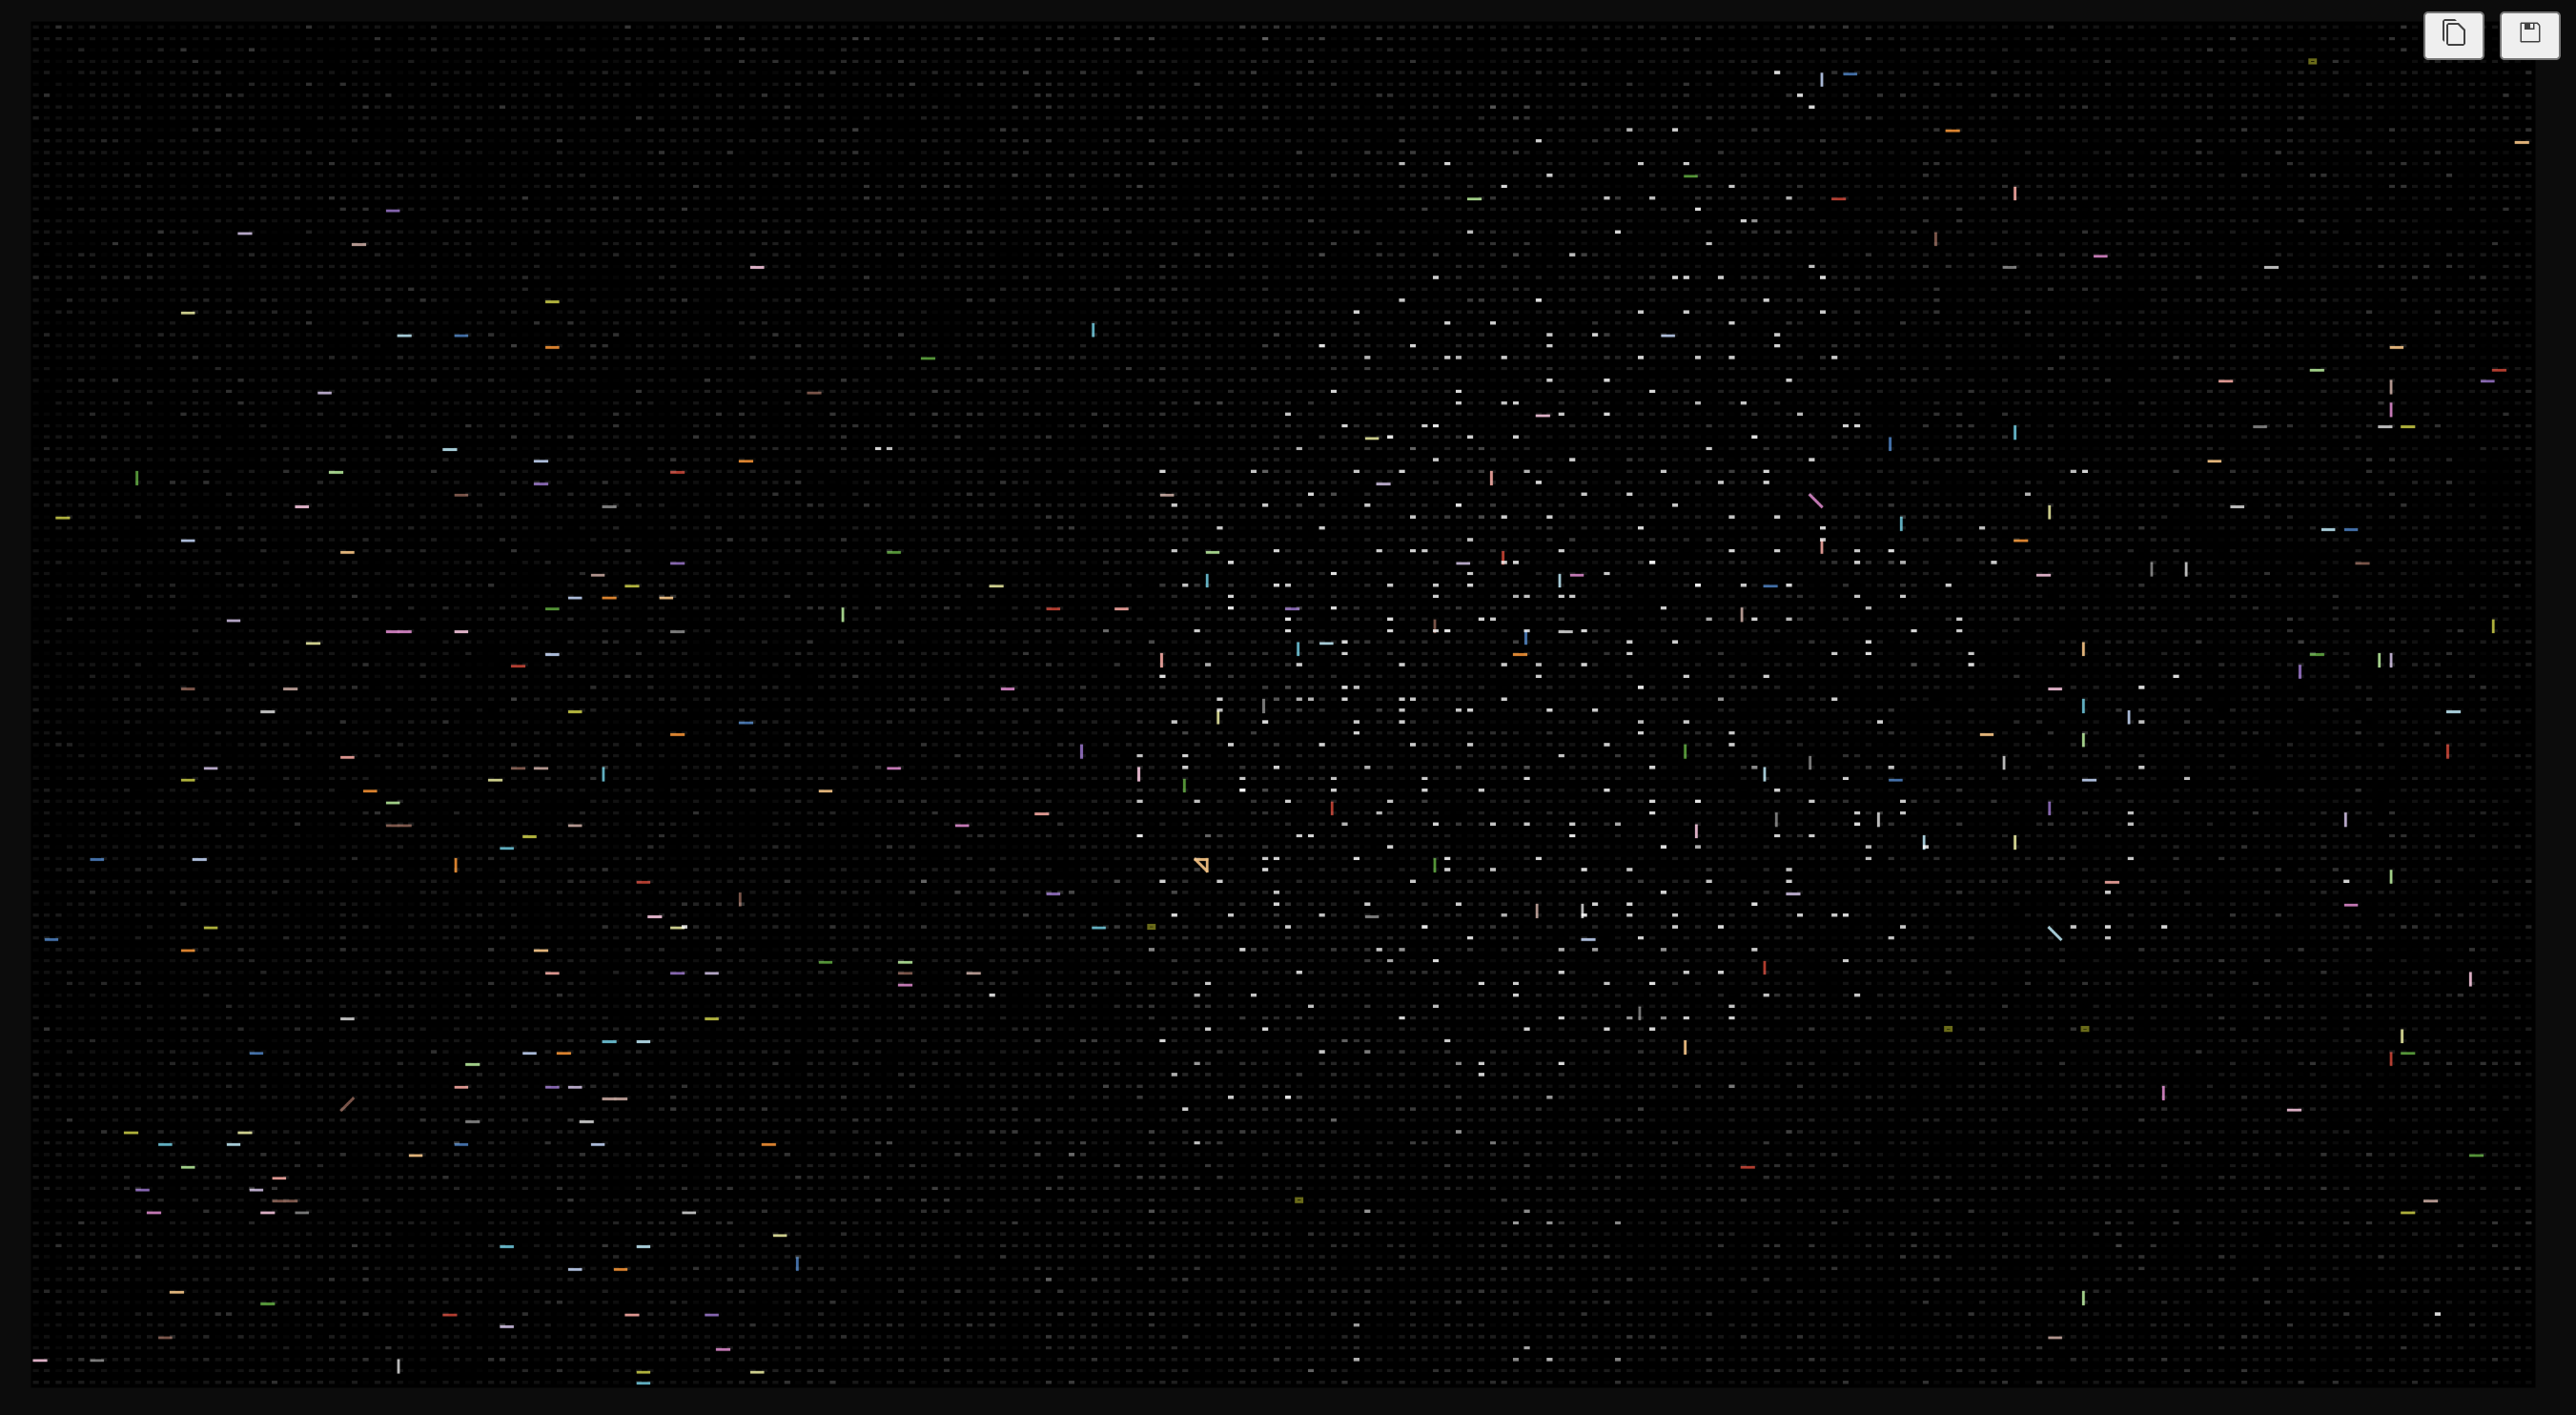
* **Important: using the current film, what should be polyimide look like??? Check profile carefully, and adapt, can it short pads?? 1024 channels device could be optimized!**
* Added singleStim based on a connectivity result, not implant_mapping, but realized that it just reproduces impedance result, everything shorted together if low imp.

#### Next steps:
* check if it has EcoFlex, and measure connectivity one more time, trying tounderstand shifts...
* disassemble and try with PI interconnect, very curious.


In [ ]:
headstage_name = "MEA1K22"
bonding_date = '260710'
HEADSTAGE_DEVICE_NAME = 'MEA1K22'
ELECTRODE_DEVICE_NAME = 'S844pad1shank'
batch = 1
IMPLANT_DEVICE_NAME = f"{bonding_date}_{HEADSTAGE_DEVICE_NAME}_{ELECTRODE_DEVICE_NAME}B{batch}"

subdir = f"devices/headstage_devices/{headstage_name}/recordings"
nas_dir = device_paths()[0]

In [ ]:
# connectivity analysis
rec_names = [
    f'2026-07-10_15.35_ACF_VRefAmpl15_Try9_PT1',
    f'2026-07-16_14.44_ACF_+manydays_VRefAmpl15_Try9_PT1',
    f'2026-07-16_14.54_ACF_VRefAmpl15_Try9_PTT2',
    f'2026-07-16_14.58_ACF_VRefAmpl15_Try9_PTT3',
]

data = []
for rec_name in rec_names:
    full_recdir = os.path.join(nas_dir, subdir, rec_name)
    # extract_connectivity(full_recdir, input_ampl_mV=10, n_samples=8000, debug=False)
    conn = get_connectivity_data(full_recdir)
    # conn.rename(columns={"el": 'mea1k_el', "connectivity": 'mea1k_connectivity'}, inplace=True)
    print(rec_name)
    (fig, ax), _ = vis.draw_mea1k(mapping=conn, cmap_scaler=1.5, fast=True)
    # save fig to local dir check_overlap
    fig.savefig('./check_overlap/' + rec_name + '_connectivity.png', dpi=300, transparent=True, bbox_inches='tight')
    data.append(conn)
    # create_implant_dir(subdir, nas_dir, HEADSTAGE_DEVICE_NAME, IMPLANT_DEVICE_NAME)
    # plt.figure()
    # plt.hist(conn.mea1k_connectivity, bins=100)
    # plt.title("Why so low? ONly 4mV? Should be 10?")
    # plt.show()

In [ ]:
vis.compare_many_connectivities(data, ['PT1', 'PT1+7days', 'PT2', 'PT3'], color_metal=False, )

In [ ]:
## short tiles
rec_dir = "2026-07-10_20.33.06_ACF_TileShorts2_Try9"
rec_dir = "2026-07-11_09.51.17_ACF_TileShorts2_Try9"
full_recdir = os.path.join(nas_dir, subdir, rec_dir)
connected_islands(full_recdir, output_dir=os.path.join(full_recdir, "processed"), 
                  conn_thr=.5, output_fname=f"connected_islands.png",
                  draw_mea_args={"mapping":conn, "el_color":"#595959", 'cmap_scaler':2})

# plot_amplitude_ridges(full_recdir, shorted_thresh=.4, n_groups=1, min_stim_uV=1000, rebuilt_graph=True)
# plot_3x3_short_results(full_recdir, bins=60, n_groups=8, shorted_thresh=0.4, dpi=100)
# connected_islands(full_recdir,
#                   output_dir=output_dir,  conn_thr=.5,
#                   output_fname=f"connected_islands.png")


In [ ]:
## short tiles
rec_dir = '2026-07-11_13.53.54_ExtConnectivity_SingleStim'
full_recdir = os.path.join(nas_dir, subdir, rec_dir)
connected_islands(full_recdir, output_dir=os.path.join(full_recdir, "processed"), 
                  conn_thr=.5, output_fname=f"connected_islands.png",
                  draw_mea_args={"mapping":conn, "el_color":"#595959", 'cmap_scaler':2})

plot_amplitude_ridges(full_recdir, shorted_thresh=.4, n_groups=1, min_stim_uV=1000, rebuilt_graph=True)
# plot_3x3_short_results(full_recdir, bins=60, n_groups=8, shorted_thresh=0.4, dpi=100)
connected_islands(full_recdir,
                  output_dir=os.path.join(full_recdir, "processed"),  conn_thr=.5,
                  output_fname=f"connected_islands.png")


In [ ]:
## impadeance

log_scale = True
rec_dir = "2026-07-10_14.36_ACF_Try9_Imp1_PT1_LC"
rec_dir = "2026-07-12_21.02_ACF_Try9_Imp2_PT1_SC"
rec_dir = "2026-07-12_19.58_ACF_Try9_Imp2_PT1_LC"

aggr_df, implant_mapping, full_recdir = load_impedance_data(rec_dir, nas_dir, subdir, )
vis.plot_impedance_analysis(rec_dir, aggr_df, log_scale=log_scale, 
                            ylims=(1_000, 2_000_000), skip_bottom=False, 
                            color_by_metal=False, use_imp_connectivity=True)
vis.plot_ext_current_comparison(aggr_df, diff_max=2_000_000, title="Small current mode")
 

In [ ]:
# second check:
rec_dir = "2026-07-12_19.58_ACF_Try9_Imp2_PT1_LC"
rec_dir = "2026-07-12_21.02_ACF_Try9_Imp2_PT1_SC"
rec_dir = "2026-07-12_19.58_ACF_Try9_Imp2_PT1_LC"
# rec_dir = "2026-07-12_21.02_ACF_Try9_Imp2_PT1_SC"
# rec_dir = "2026-07-16_15.02_ACF_PT3_LC"

aggr_df, implant_mapping, full_recdir = load_impedance_data(rec_dir, nas_dir, subdir, )
_ = vis.plot_impedance_analysis(rec_dir, aggr_df, log_scale=True, 
                            ylims=(1_000, 2_000_000), skip_bottom=False, 
                            color_by_metal=False, use_imp_connectivity=True)
print(f"n electrodes with connectivity > .33: {np.sum(aggr_df.connectivity > .33)}")
print(f"Of that, n electrodes with low impedance connection: {np.sum((aggr_df.connectivity > .33) & (aggr_df.impedance_Ohm < 10_000))}, "
      f"{np.sum((aggr_df.connectivity > .33) & (aggr_df.impedance_Ohm < 10_000)) / np.sum(aggr_df.connectivity > .33) * 100:.2f} %")

MONDAY 13.7

First bond with ACF, silver paint+wire to GND. Ohmic bond:) MEthod works. WIll connect 100K R. ALso clearly saw DC shift for the firs ttime. How calibration affects it. But could not resolve yet why characterization differs from here. Range of limited to ±1.3V only? low battery i assume. Then i can understand better the affects of DC shifting. 

Here StimUnit 16 is not fully calibrated, shift by 2 to center properly, but current is clipped
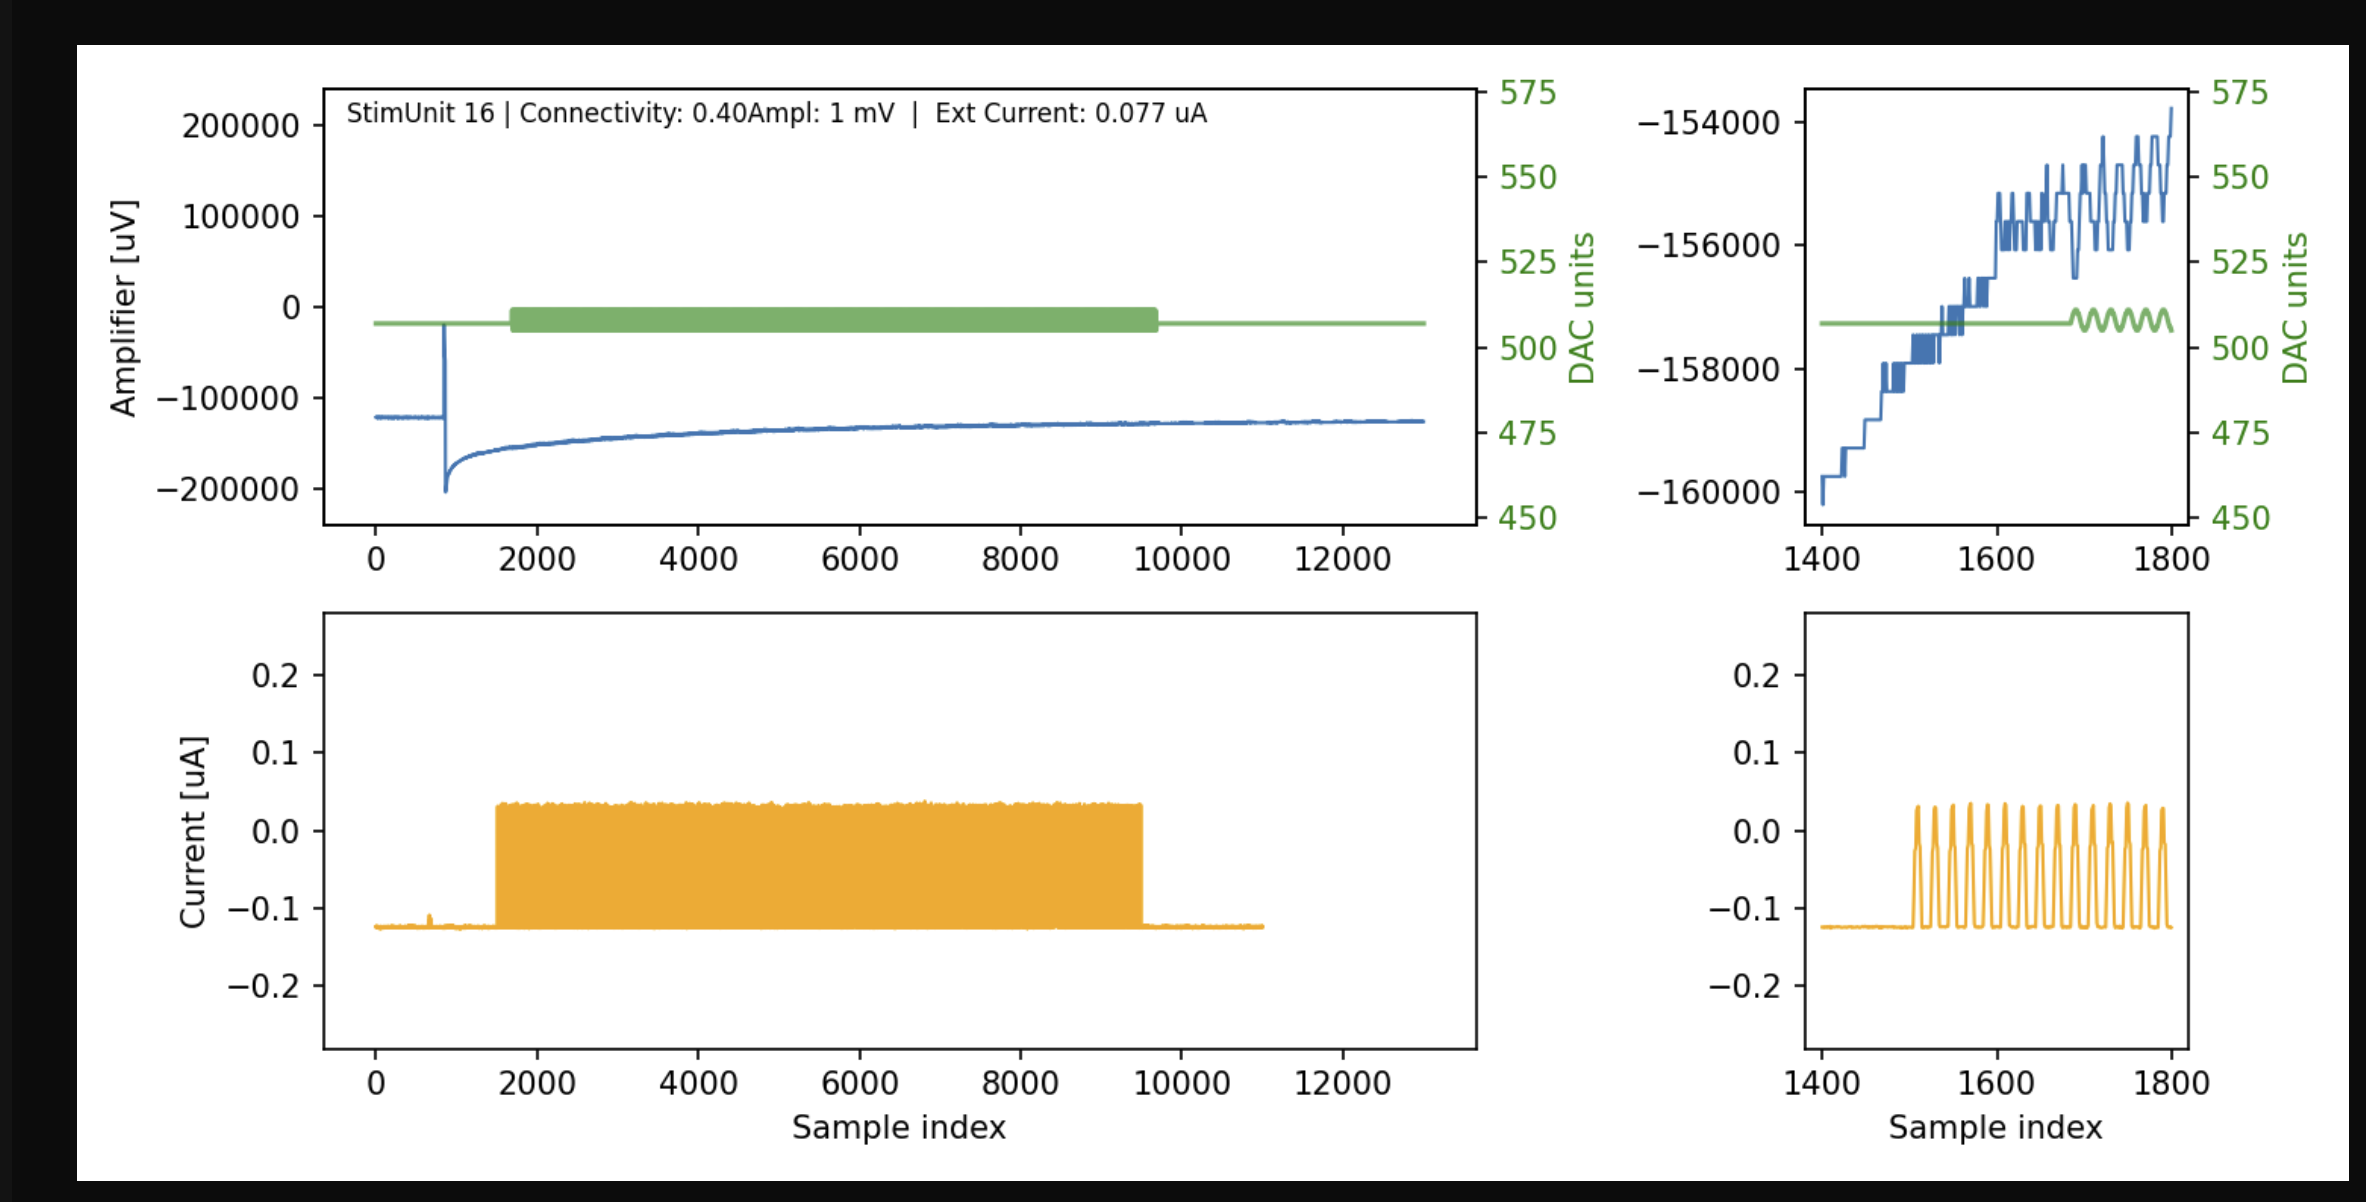

Wafter shfiting by2: sine looks fixed, but DC offset only very little no? Maybe clue about
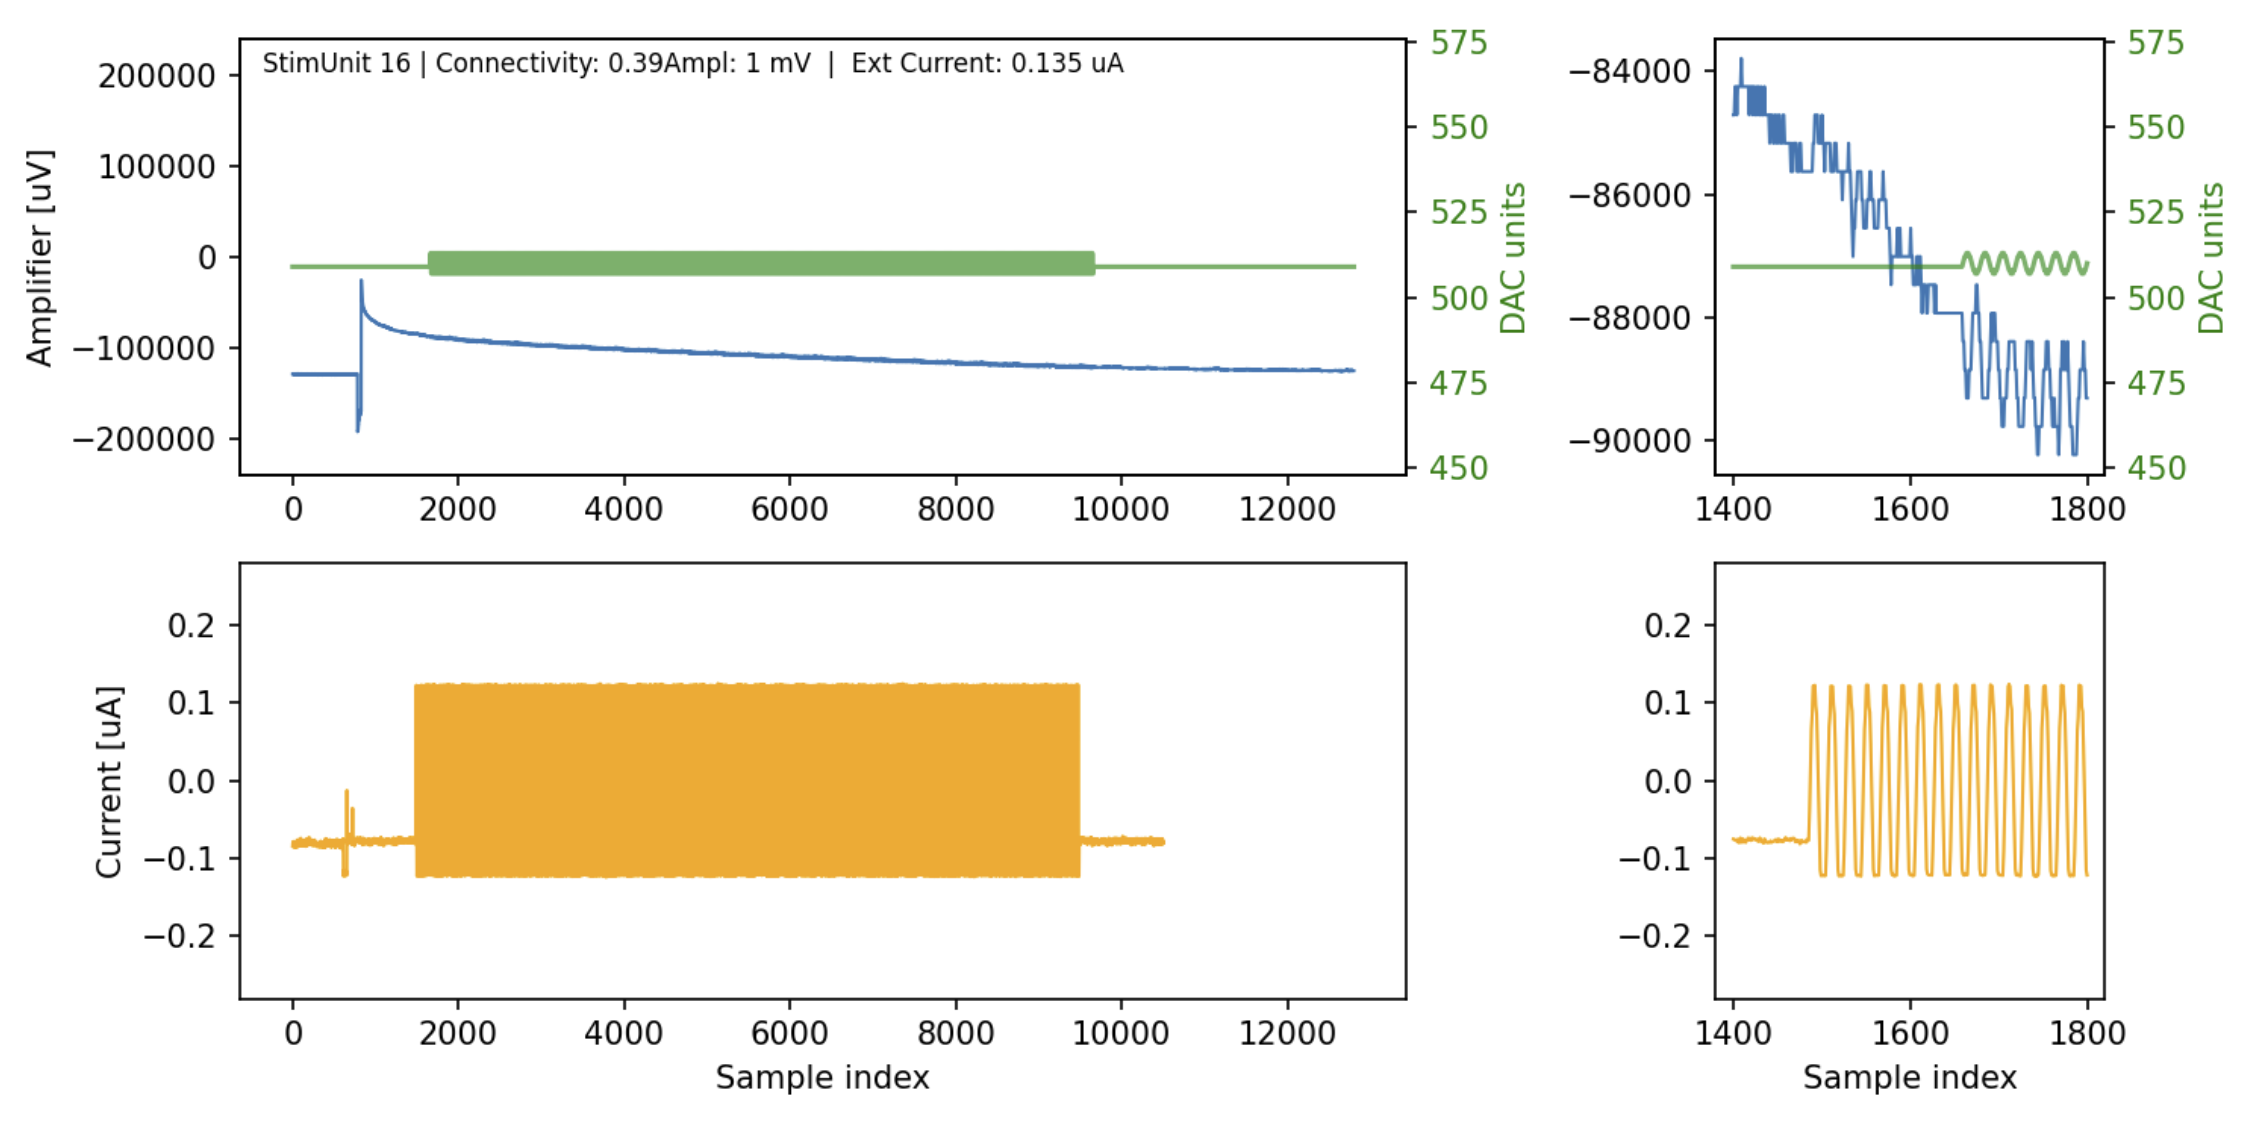


# history:




## MEA22:

* There was exploration with chip before as i can see test bonds mid april, for example testBond2 and testBond4 ShubhamWafer1, it looked quite good! 
![alt text](image-14.png)
![alt text](image-13.png)
![alt text](image-15.png)

#### Bond2
* I think i started with this one in a serious way. First real attempt with Shubham's devices. Called it **Bond2**. ShubhamW3, mid april, looked very promising. Here i still used copper wire through... copper deterioartion. And shorts issue. Wanted to hook this one, but then got demotivated by shorts.  Could recheck Still was using SC back then, discovered LC later, and did frequency checks.  Measured this one like hell. I started using Gallium, which never fully worked, i actually never fully looked at it if i rmember now... Gallium then harded and shanks ripped... lost one ofter the other like this, in the end also tried silver paint which looked much better. Eventually, i also imaged this with Anna, and i spotted gold on the ring electrodes, suggesting potential for shorts.

![alt text](image-11.png)
![alt text](image-10.png) 

#### Bond5
* So this is the most recent one, late June, so long break for MEA22 (misnamed it before as MEA23, now fixed). High pressure using EcoFlex00-10, disappointed. Had Silk, but overall bad impdance, but also measurements with stimUnits quite unstable... Now Firday, should check this evening... ANd confirmation from last bond (bond2) there seems to be an issue with the gold there, again patchy, high pressure needed. pickup was kinda messy and accidentally scaped polyimide cable once...
![alt text](image-18.png)
![alt text](image-16.png)
![alt text](image-17.png)

Problems... there are again signicant shorts, and now very clearly organized the way they are routed out.
![alt text](image-23.png)
![alt text](image-24.png)




Not sure if there was something in between, but next imporant thing was ACF film attempt, first time working here:

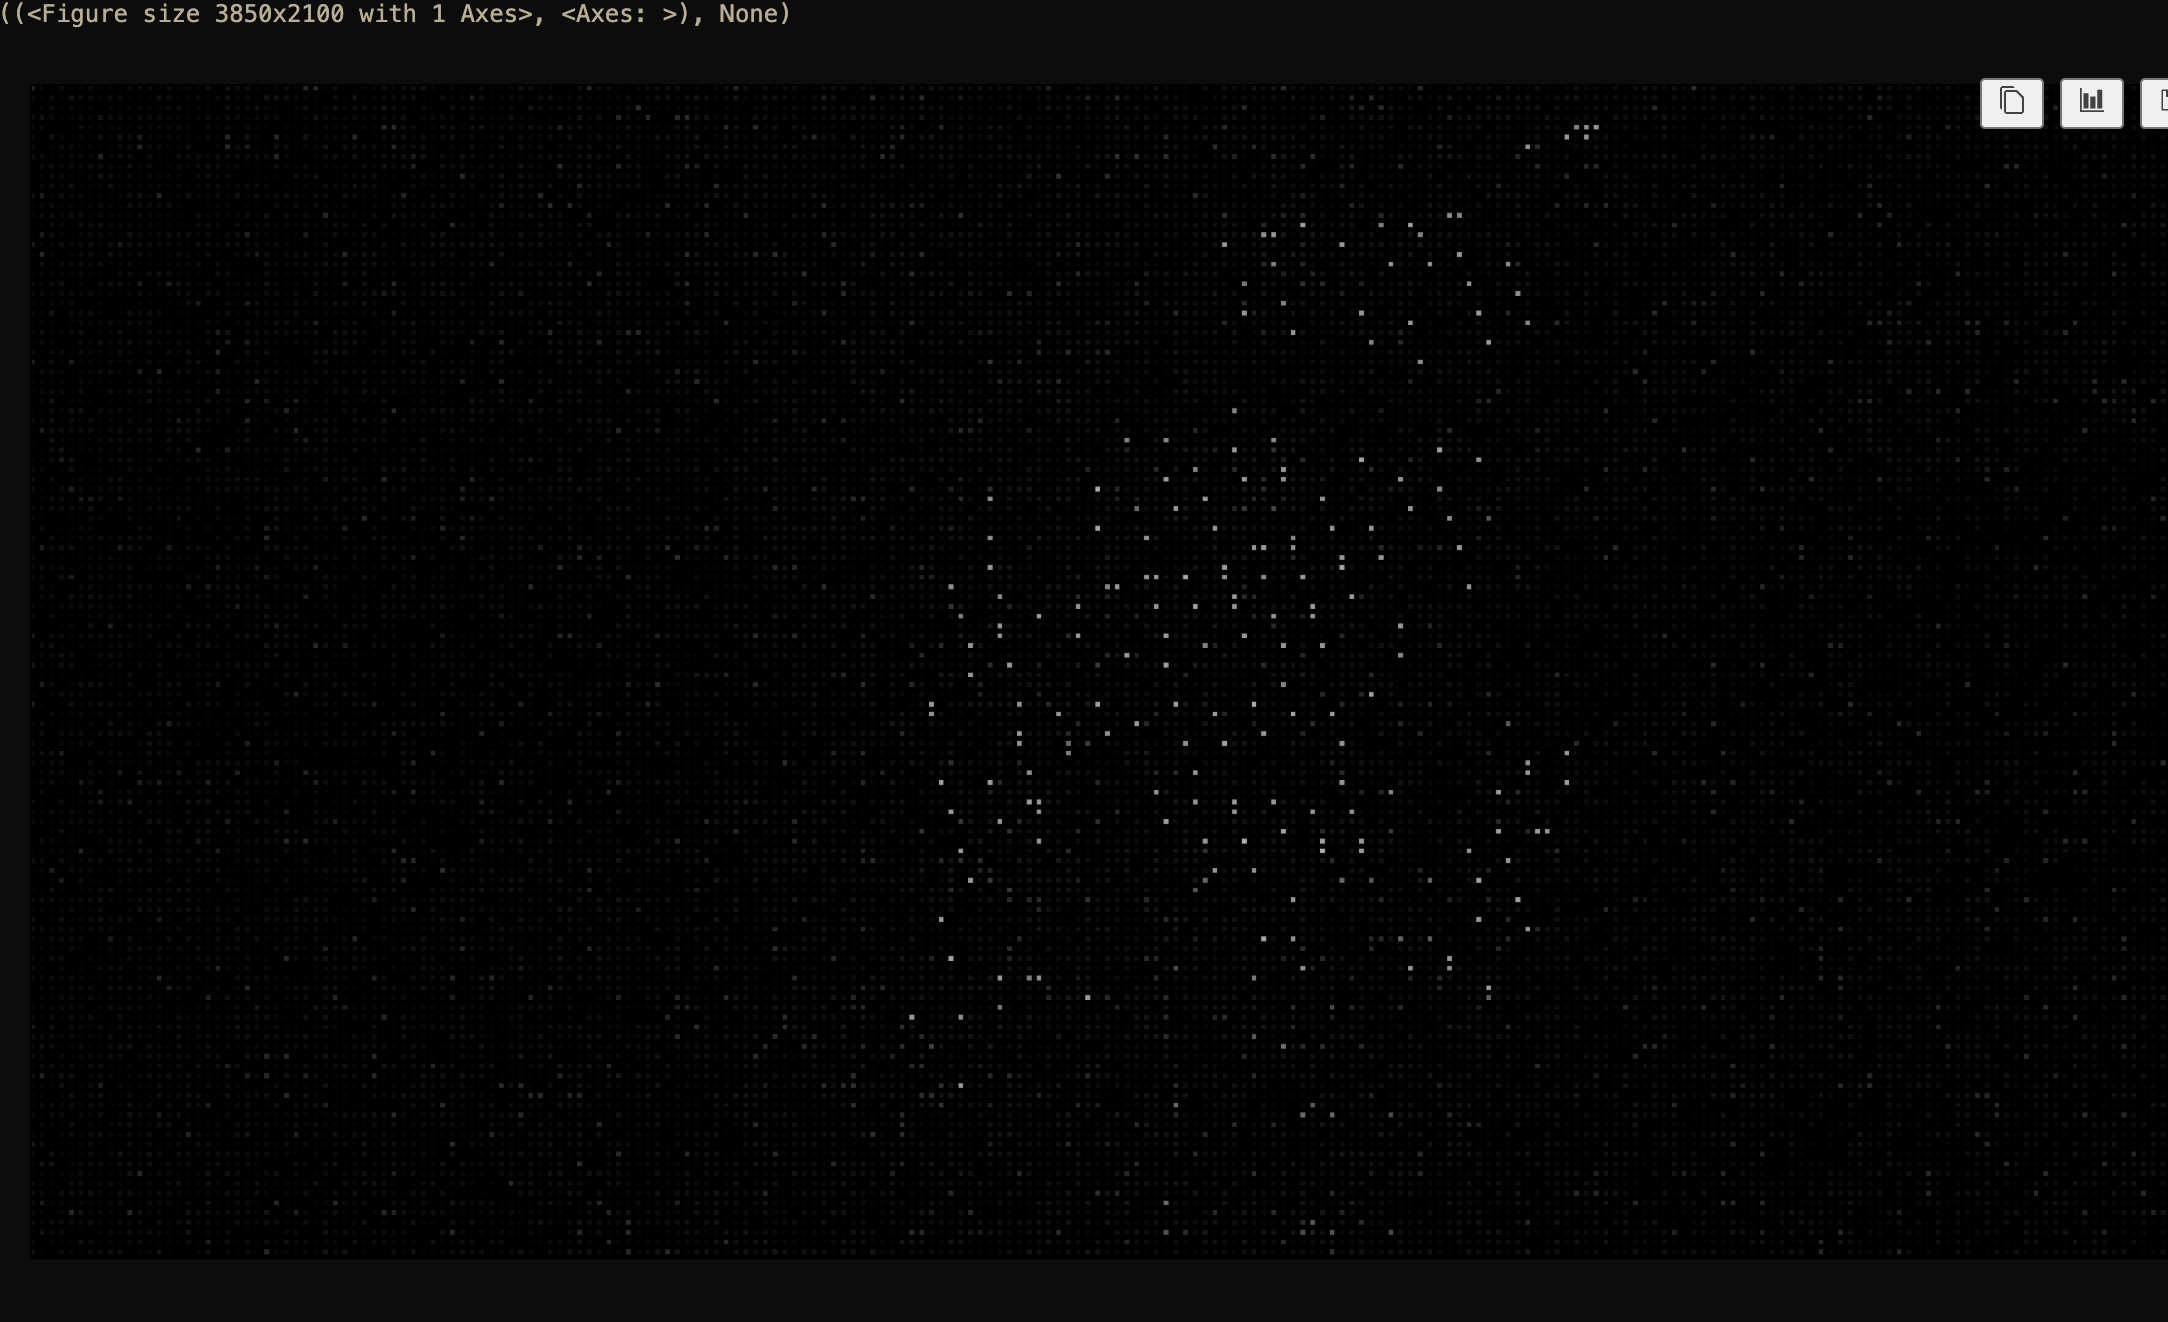